# Análisis de Engagement en Globant con Cadenas de Markov

**Objetivo general**

- Modelar la evolución del engagement de los empleados de Globant mediante **cadenas de Markov**.
- Comparar cómo cambia el engagement según:
  - Proyecto (`Project Tag`)
  - Seniority (`Seniority`)
  - (Opcional) Position / Location
- Obtener **insights accionables**: proyectos/segmentos que favorecen mejorar el engagement vs. aquellos donde tiende a deteriorarse.

---

## 0. Setup e importación de funciones

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append("../scripts")

sns.set(style="whitegrid")

# Si markov_engagement.py está en la misma carpeta que este notebook:
from markov_engagement import (
    build_transition_matrix,
    estacionaria,
    prob_mejorar,
    prob_empeorar,
    engagement_estacionario,
    DEFAULT_STATES,
)

states = DEFAULT_STATES  # [1,2,3,4,5]

## 1. Carga y preprocesamiento de datos

In [2]:
# Ruta al CSV limpio
data_path = "../data/data_globant_cleaned.csv"

data = pd.read_csv(data_path)

# Conversión de fecha
data["Date"] = pd.to_datetime(data["Date"])

# Filtrar estados válidos (quitar Engagement Group = 0 si existe)
data = data[data["Engagement Group"] > 0].copy()

# Ordenar por persona y tiempo para garantizar transiciones correctas
data = data.sort_values(["Name", "Date"])

data.head()

,Date,Name,Position,Seniority,Location,Studio,Client Tag,Project Tag,Team Name,Engagement,Leader Name,Engagement Group
6005,2023-01-02,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.40,Pedro Rodriguez,4
6006,2023-01-03,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.62,Pedro Rodriguez,4
6007,2023-01-04,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.73,Pedro Rodriguez,4
6008,2023-01-05,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,4.21,Pedro Rodriguez,5
6009,2023-01-06,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.91,Pedro Rodriguez,5


### 1.1 Vista rápida del dataset

In [3]:
print("Shape:", data.shape)
display(data.describe(include="all").T)

print("\nValores únicos de algunas columnas clave:")
for col in ["Project Tag", "Seniority", "Position", "Location"]:
    if col in data.columns:
        print(f"\n{col}:")
        print(data[col].value_counts().head(10))

Shape: (11098, 12)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,11098,NaN,NaN,NaN,2023-04-02 01:02:55.815462144,2023-01-02 00:00:00,2023-02-15 00:00:00,2023-04-03 00:00:00,2023-05-18 00:00:00,2023-06-30 00:00:00,NaN
Name,11098,94,Juan Soto,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Position,11098,15,Software Developer,4046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seniority,11098,5,Sr Level 1,3796,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,11098,6,AR/CABA/BA,3466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Studio,11098,7,Engineering,4571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Client Tag,11098,5,EDUSYS,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project Tag,11098,8,CATPRO,2403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Team Name,11098,10,Jurassic Bark,1371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engagement,11098.0,NaN,NaN,NaN,3.067582,0.03,2.55,3.08,3.61,5.0,0.901902



Valores únicos de algunas columnas clave:

Project Tag:
Project Tag
CATPRO    2403
NEXDEV    2370
VGRDIN    1234
ATLINT    1134
STYPRJ    1105
ODYQST    1007
HOREXP     976
ECOSYS     869
Name: count, dtype: int64

Seniority:
Seniority
Sr Level 1    3796
Ssr           3721
Sr Level 2    1889
Jr            1320
Sr Level 3     372
Name: count, dtype: int64

Position:
Position
Software Developer          4046
Test Automation Engineer    1377
Quality Assurance Tester    1007
Project Manager              866
Business Analyst             794
DevOps Engineer              616
Data Analyst                 487
User Experience Designer     294
Visual Designer              285
Solutions Architect          284
Name: count, dtype: int64

Location:
Location
AR/CABA/BA        3466
CO/CUN/BOG        2692
MX/CDMX/CDMX      1807
CL/RM/SCL         1350
CO/ANT/MED        1208
MX/JALISCO/GDL     575
Name: count, dtype: int64


## 2. Cadena de Markov global de engagement

En esta sección estimamos una **cadena de Markov global**:
- Estados = niveles de `Engagement Group` (1–5).
- Transiciones intra-persona a lo largo del tiempo.
- Métricas:
  - Probabilidad promedio de **mejorar** de estado.
  - Probabilidad promedio de **empeorar** de estado.
  - Distribución estacionaria.
  - Engagement esperado de largo plazo.

In [4]:
P_global = build_transition_matrix(data, col_state="Engagement Group", states=states)

pi_global = estacionaria(P_global)
p_up_global = prob_mejorar(P_global, states=states)
p_down_global = prob_empeorar(P_global, states=states)
E_inf_global = engagement_estacionario(pi_global, states=states)

print("Matriz de transición global (redondeada):\n", np.round(P_global, 3))
print("\nDistribución estacionaria global π:", np.round(pi_global, 3))
print("\nProbabilidad promedio de mejorar (global):", p_up_global)
print("Probabilidad promedio de empeorar (global):", p_down_global)
print("Engagement esperado estacionario (global):", E_inf_global)

Matriz de transición global (redondeada):
 [[0.698 0.151 0.069 0.043 0.039]
 [0.163 0.509 0.203 0.12  0.006]
 [0.072 0.221 0.424 0.232 0.051]
 [0.044 0.106 0.265 0.394 0.191]
 [0.039 0.007 0.054 0.193 0.708]]

Distribución estacionaria global π: [0.21  0.2   0.203 0.194 0.194]

Probabilidad promedio de mejorar (global): 0.22082912055936724
Probabilidad promedio de empeorar (global): 0.23274271777369018
Engagement esperado estacionario (global): 2.9614546033012212


### 2.1 Visualización de la matriz de transición global

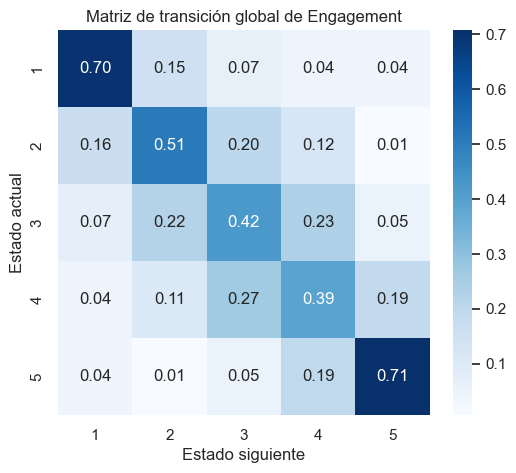

In [5]:
plt.figure(figsize=(6,5))
sns.heatmap(P_global, annot=True, fmt=".2f",
            xticklabels=states, yticklabels=states, cmap="Blues")
plt.xlabel("Estado siguiente")
plt.ylabel("Estado actual")
plt.title("Matriz de transición global de Engagement")
plt.show()

### 2.2 Distribución estacionaria global

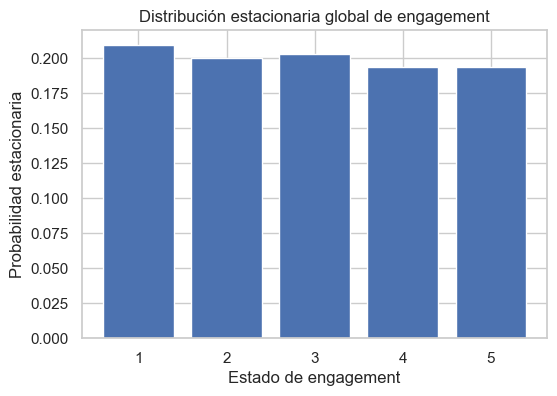

In [6]:
plt.figure(figsize=(6,4))
plt.bar(states, pi_global)
plt.xlabel("Estado de engagement")
plt.ylabel("Probabilidad estacionaria")
plt.title("Distribución estacionaria global de engagement")
plt.xticks(states)
plt.show()

## 3. Análisis por proyecto (`Project Tag`)

Ahora estimamos una cadena de Markov **para cada Project Tag** con suficiente información:

Para cada proyecto:
- Matriz de transición `P_proj`
- Probabilidad de mejorar / empeorar
- Distribución estacionaria
- Engagement esperado estacionario

Esto nos permite rankear proyectos según su impacto en el engagement de largo plazo.

In [7]:
results_proj = []

min_rows = 30  # umbral mínimo de tamaño de grupo (ajustable)

for proj in data["Project Tag"].dropna().unique():
    sub = data[data["Project Tag"] == proj]
    
    if sub.shape[0] < min_rows:
        continue  # muy pocos datos
    
    P = build_transition_matrix(sub, col_state="Engagement Group", states=states)
    
    if P.sum() == 0:
        continue  # sin transiciones válidas
    
    pi = estacionaria(P)
    p_up = prob_mejorar(P, states=states)
    p_down = prob_empeorar(P, states=states)
    E_inf = engagement_estacionario(pi, states=states)
    
    results_proj.append({
        "Project Tag": proj,
        "n_registros": sub.shape[0],
        "prob_mejorar": p_up,
        "prob_empeorar": p_down,
        "engagement_estacionario": E_inf
    })

df_proj = pd.DataFrame(results_proj)

df_proj_sorted = df_proj.sort_values(
    "engagement_estacionario", ascending=False
).reset_index(drop=True)

df_proj_sorted

,Project Tag,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,NEXDEV,2370,0.256597,0.232590,3.180931
1,ODYQST,1007,0.205532,0.197080,3.093255
2,CATPRO,2403,0.236953,0.221493,3.088851
3,ECOSYS,869,0.221078,0.204310,3.043863
4,HOREXP,976,0.116800,0.187671,2.939377
5,VGRDIN,1234,0.232301,0.246727,2.928922
6,STYPRJ,1105,0.190411,0.290900,2.483167
7,ATLINT,1134,0.176289,0.290018,2.404083


### 3.1 Ranking de proyectos por engagement estacionario

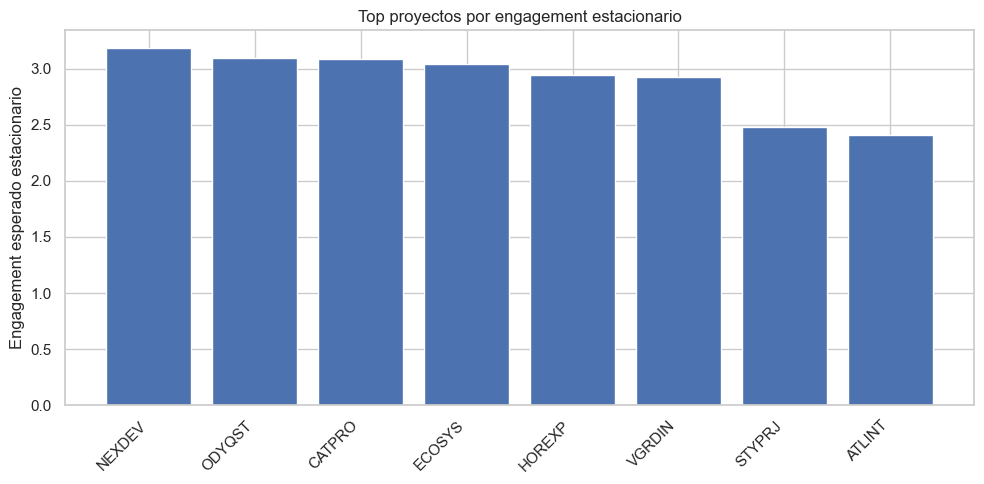

In [8]:
plt.figure(figsize=(10,5))
top_n = min(10, df_proj_sorted.shape[0])
plt.bar(df_proj_sorted["Project Tag"].head(top_n),
        df_proj_sorted["engagement_estacionario"].head(top_n))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Engagement esperado estacionario")
plt.title("Top proyectos por engagement estacionario")
plt.tight_layout()
plt.show()

### 3.2 Visualización de matrices de transición y estacionarias para proyectos clave

Tomaremos algunos proyectos:
- Top 3 con mayor engagement estacionario
- (Opcional) Bottom 3 con menor engagement estacionario

In [9]:
top_projects = df_proj_sorted["Project Tag"].head(3).tolist()
bottom_projects = df_proj_sorted["Project Tag"].tail(3).tolist()

def plot_markov_for_project(proj_name):
    sub = data[data["Project Tag"] == proj_name]
    P = build_transition_matrix(sub, col_state="Engagement Group", states=states)
    pi = estacionaria(P)
    
    print(f"\n=== Proyecto: {proj_name} ===")
    print("Matriz de transición (redondeada):\n", np.round(P, 3))
    print("Distribución estacionaria:", np.round(pi, 3))
    print("Engagement estacionario:", engagement_estacionario(pi, states=states))
    
    # Heatmap de P
    plt.figure(figsize=(6,5))
    sns.heatmap(P, annot=True, fmt=".2f",
                xticklabels=states, yticklabels=states, cmap="Blues")
    plt.xlabel("Estado siguiente")
    plt.ylabel("Estado actual")
    plt.title(f"Matriz de transición - {proj_name}")
    plt.show()
    
    # Distribución estacionaria
    plt.figure(figsize=(6,4))
    plt.bar(states, pi)
    plt.xlabel("Estado")
    plt.ylabel("Probabilidad")
    plt.title(f"Distribución estacionaria de engagement - {proj_name}")
    plt.xticks(states)
    plt.show()

print("Proyectos TOP:", top_projects)
print("Proyectos BOTTOM:", bottom_projects)

Proyectos TOP: ['NEXDEV', 'ODYQST', 'CATPRO']
Proyectos BOTTOM: ['VGRDIN', 'STYPRJ', 'ATLINT']



=== Proyecto: NEXDEV ===
Matriz de transición (redondeada):
 [[0.643 0.138 0.068 0.076 0.076]
 [0.146 0.549 0.187 0.118 0.   ]
 [0.055 0.205 0.353 0.312 0.075]
 [0.048 0.075 0.234 0.408 0.234]
 [0.047 0.002 0.074 0.277 0.6  ]]
Distribución estacionaria: [0.164 0.178 0.186 0.256 0.216]
Engagement estacionario: 3.1809312463923276


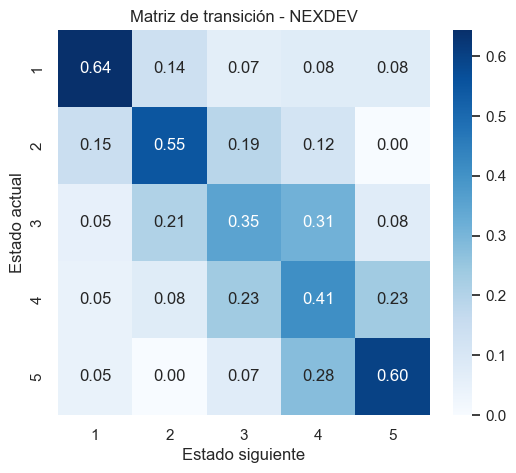

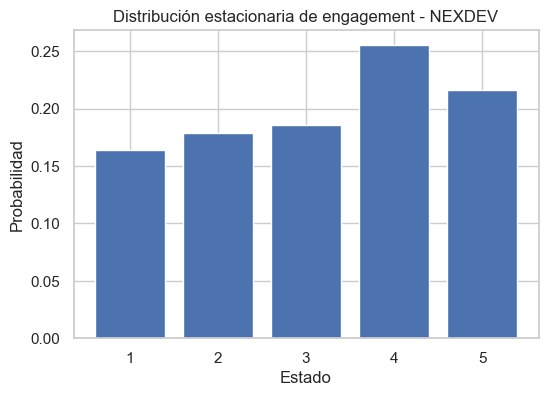


=== Proyecto: ODYQST ===
Matriz de transición (redondeada):
 [[0.73  0.162 0.034 0.02  0.054]
 [0.094 0.692 0.12  0.094 0.   ]
 [0.033 0.243 0.474 0.191 0.059]
 [0.017 0.126 0.201 0.362 0.293]
 [0.031 0.004 0.027 0.208 0.73 ]]
Distribución estacionaria: [0.153 0.273 0.151 0.172 0.25 ]
Engagement estacionario: 3.0932553916142114


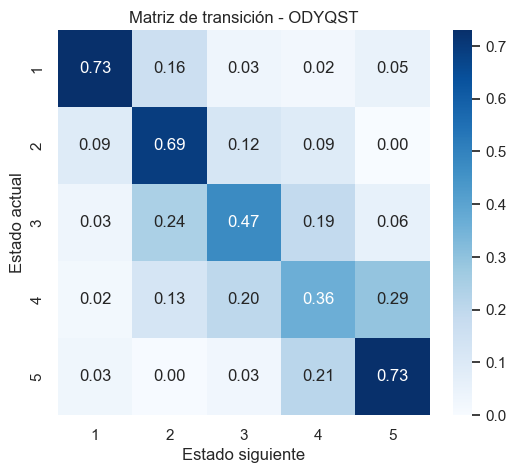

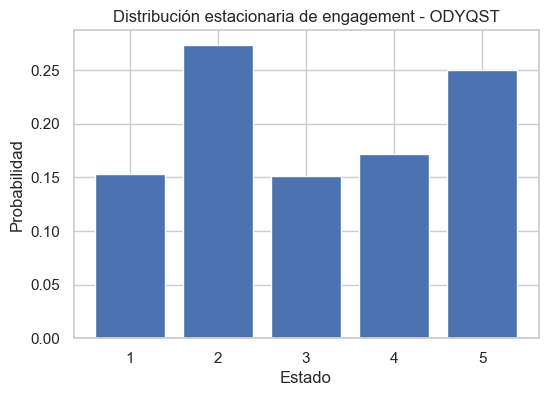


=== Proyecto: CATPRO ===
Matriz de transición (redondeada):
 [[0.741 0.154 0.048 0.04  0.018]
 [0.203 0.485 0.182 0.127 0.003]
 [0.066 0.184 0.35  0.335 0.066]
 [0.032 0.067 0.258 0.43  0.213]
 [0.021 0.002 0.065 0.209 0.703]]
Distribución estacionaria: [0.214 0.158 0.174 0.234 0.22 ]
Engagement estacionario: 3.0888514939347473


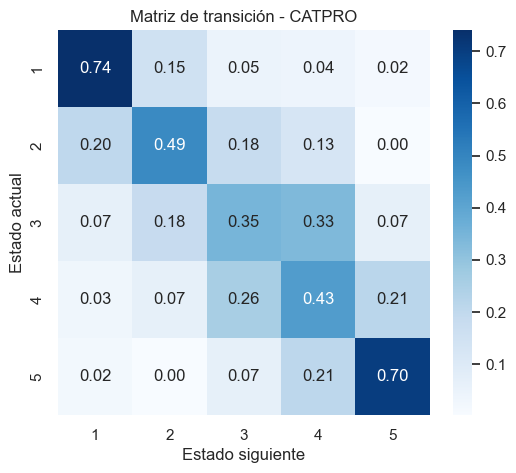

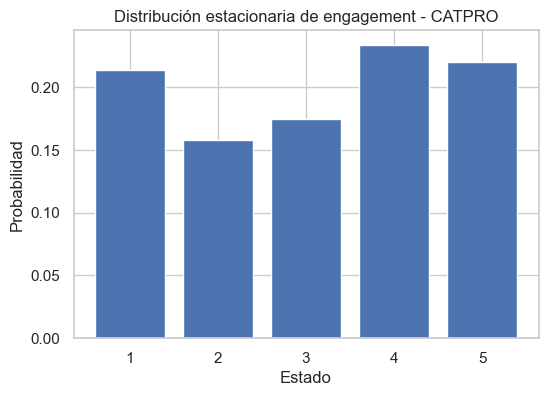


=== Proyecto: VGRDIN ===
Matriz de transición (redondeada):
 [[0.6   0.293 0.084 0.009 0.013]
 [0.269 0.368 0.26  0.103 0.   ]
 [0.065 0.141 0.524 0.231 0.039]
 [0.023 0.114 0.388 0.347 0.128]
 [0.015 0.005 0.04  0.174 0.766]]
Distribución estacionaria: [0.188 0.186 0.292 0.177 0.157]
Engagement estacionario: 2.928921756588906


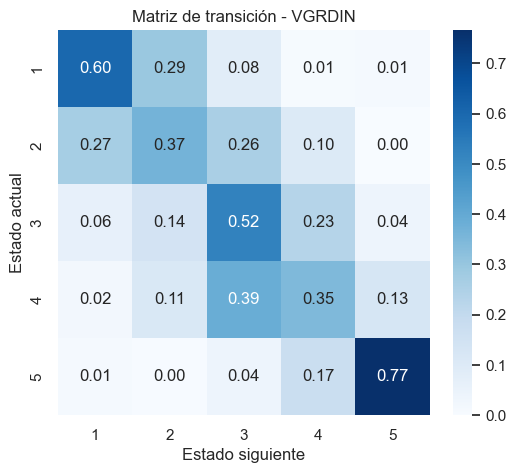

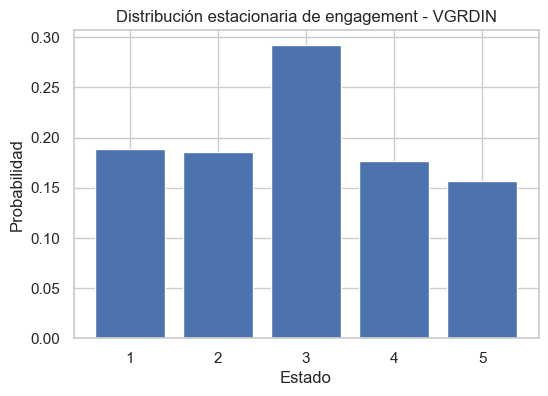


=== Proyecto: STYPRJ ===
Matriz de transición (redondeada):
 [[0.71  0.149 0.09  0.024 0.027]
 [0.136 0.435 0.328 0.101 0.   ]
 [0.064 0.344 0.437 0.145 0.01 ]
 [0.053 0.204 0.296 0.368 0.079]
 [0.086 0.014 0.086 0.171 0.643]]
Distribución estacionaria: [0.239 0.286 0.285 0.135 0.056]
Engagement estacionario: 2.4831667207700048


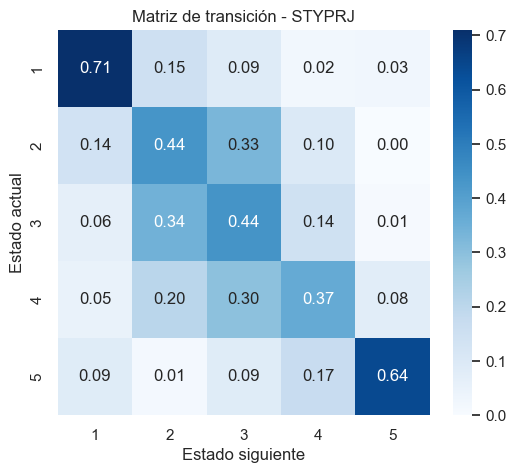

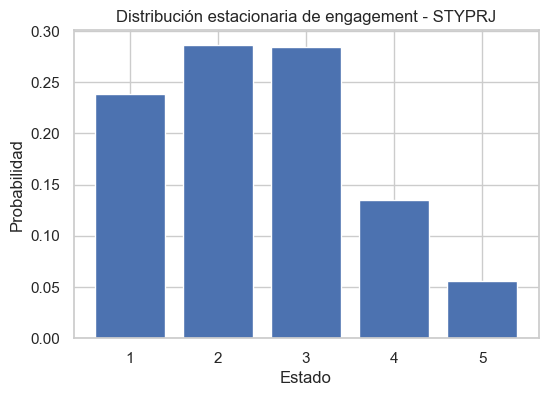


=== Proyecto: ATLINT ===
Matriz de transición (redondeada):
 [[0.761 0.152 0.048 0.029 0.01 ]
 [0.335 0.386 0.181 0.098 0.   ]
 [0.113 0.251 0.364 0.221 0.051]
 [0.037 0.135 0.35  0.387 0.092]
 [0.007 0.    0.059 0.163 0.77 ]]
Distribución estacionaria: [0.381 0.196 0.172 0.14  0.111]
Engagement estacionario: 2.404083207308954


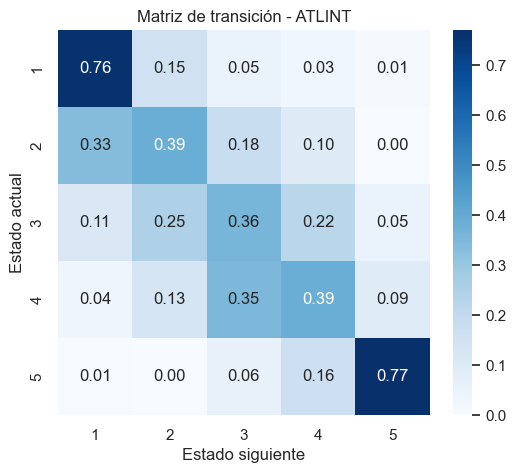

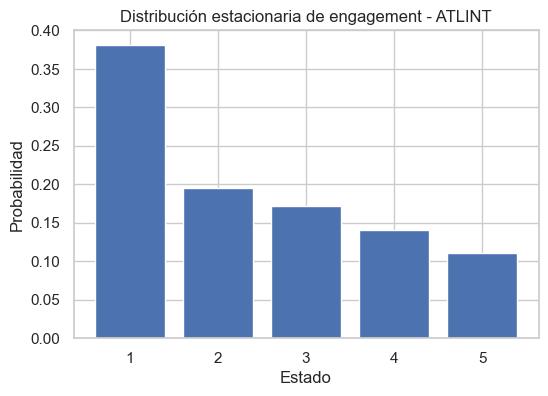

In [10]:
# Graficar para Top 3
for proj in top_projects:
    plot_markov_for_project(proj)

# (Opcional) Graficar para Bottom 3
for proj in bottom_projects:
    plot_markov_for_project(proj)

## 4. Análisis por Seniority (`Seniority`)

Repetimos el procedimiento anterior, ahora segmentando por seniority:
- ¿Los Juniors y Seniors tienen dinámicas de engagement distintas?

In [11]:
results_sen = []

for sen in data["Seniority"].dropna().unique():
    sub = data[data["Seniority"] == sen]
    
    if sub.shape[0] < min_rows:
        continue
    
    P = build_transition_matrix(sub, col_state="Engagement Group", states=states)
    if P.sum() == 0:
        continue
    
    pi = estacionaria(P)
    p_up = prob_mejorar(P, states=states)
    p_down = prob_empeorar(P, states=states)
    E_inf = engagement_estacionario(pi, states=states)
    
    results_sen.append({
        "Seniority": sen,
        "n_registros": sub.shape[0],
        "prob_mejorar": p_up,
        "prob_empeorar": p_down,
        "engagement_estacionario": E_inf
    })

df_sen = pd.DataFrame(results_sen).sort_values(
    "engagement_estacionario", ascending=False
).reset_index(drop=True)

df_sen

,Seniority,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,Sr Level 3,372,0.258059,0.133513,3.952811
1,Jr,1320,0.249358,0.154263,3.406132
2,Sr Level 1,3796,0.255160,0.214877,3.271154
3,Sr Level 2,1889,0.219988,0.301927,2.667818
4,Ssr,3721,0.183284,0.253754,2.516397


### 4.1 Comparación gráfica por seniority

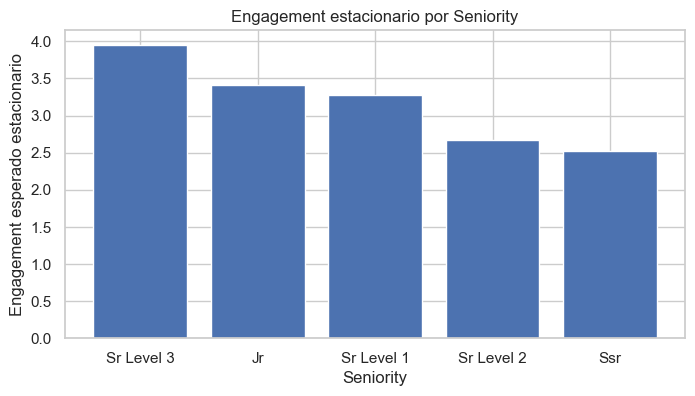

In [12]:
plt.figure(figsize=(8,4))
plt.bar(df_sen["Seniority"], df_sen["engagement_estacionario"])
plt.xlabel("Seniority")
plt.ylabel("Engagement esperado estacionario")
plt.title("Engagement estacionario por Seniority")
plt.show()


=== Seniority: Sr Level 3 ===
Matriz de transición (redondeada):
 [[0.35  0.35  0.05  0.1   0.15 ]
 [0.133 0.711 0.111 0.044 0.   ]
 [0.049 0.066 0.59  0.23  0.066]
 [0.    0.034 0.293 0.483 0.19 ]
 [0.022 0.    0.011 0.059 0.908]]
Distribución estacionaria: [0.054 0.12  0.161 0.151 0.515]
Engagement estacionario: 3.9528105818119603


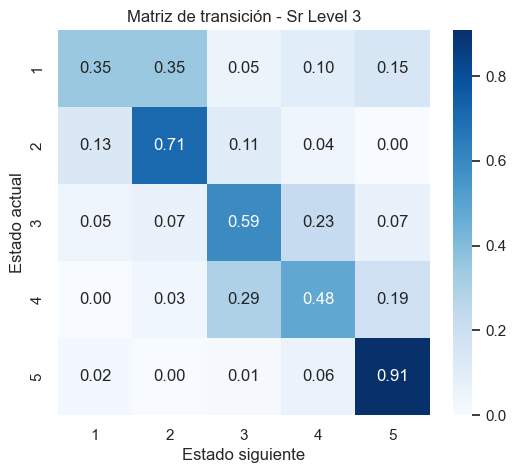


=== Seniority: Jr ===
Matriz de transición (redondeada):
 [[0.412 0.088 0.279 0.029 0.191]
 [0.024 0.774 0.136 0.066 0.   ]
 [0.056 0.115 0.614 0.187 0.028]
 [0.019 0.087 0.223 0.43  0.242]
 [0.03  0.    0.022 0.196 0.753]]
Distribución estacionaria: [0.053 0.226 0.25  0.203 0.268]
Engagement estacionario: 3.406132391809781


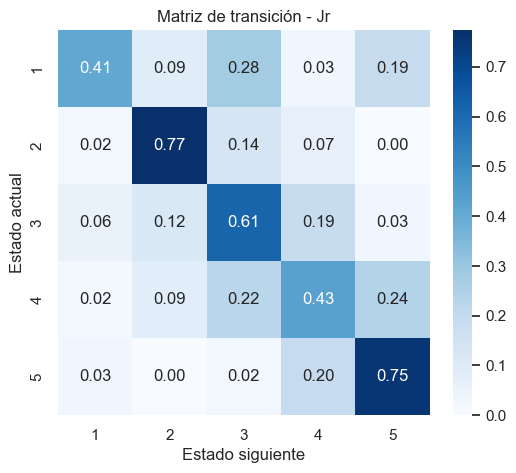


=== Seniority: Sr Level 1 ===
Matriz de transición (redondeada):
 [[0.646 0.13  0.074 0.066 0.084]
 [0.165 0.59  0.163 0.075 0.007]
 [0.078 0.171 0.346 0.297 0.108]
 [0.05  0.046 0.209 0.424 0.271]
 [0.051 0.005 0.062 0.238 0.644]]
Distribución estacionaria: [0.179 0.153 0.159 0.236 0.273]
Engagement estacionario: 3.271154193454871


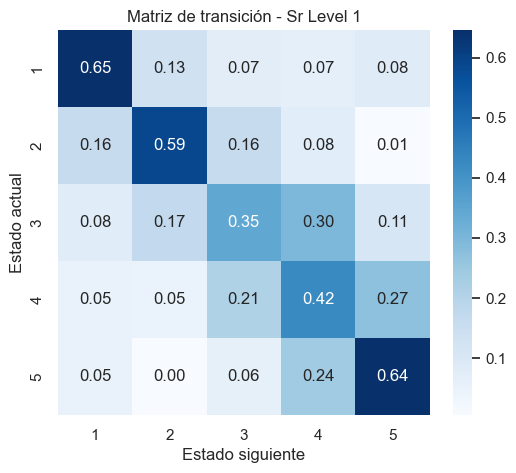


=== Seniority: Sr Level 2 ===
Matriz de transición (redondeada):
 [[0.713 0.181 0.074 0.029 0.003]
 [0.131 0.367 0.315 0.187 0.   ]
 [0.051 0.275 0.438 0.211 0.025]
 [0.024 0.185 0.395 0.32  0.075]
 [0.031 0.01  0.115 0.292 0.552]]
Distribución estacionaria: [0.191 0.249 0.313 0.195 0.052]
Engagement estacionario: 2.667817866830547


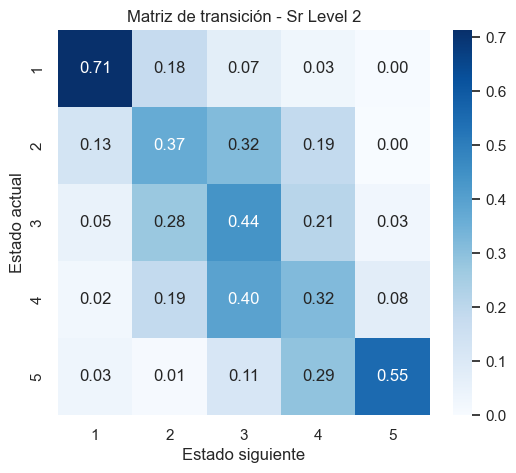


=== Seniority: Ssr ===
Matriz de transición (redondeada):
 [[0.766 0.174 0.034 0.018 0.008]
 [0.26  0.452 0.191 0.094 0.002]
 [0.069 0.26  0.395 0.245 0.031]
 [0.023 0.134 0.306 0.417 0.12 ]
 [0.016 0.002 0.065 0.133 0.784]]
Distribución estacionaria: [0.326 0.225 0.178 0.149 0.122]
Engagement estacionario: 2.5163973718815775


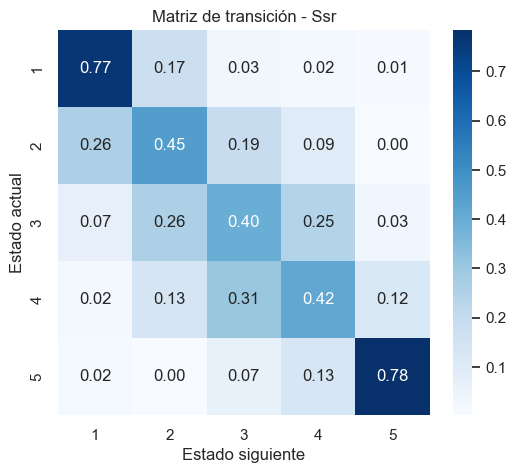

In [13]:
# Matrices y estacionarias para cada seniority
for sen in df_sen["Seniority"]:
    sub = data[data["Seniority"] == sen]
    P = build_transition_matrix(sub, col_state="Engagement Group", states=states)
    pi = estacionaria(P)
    
    print(f"\n=== Seniority: {sen} ===")
    print("Matriz de transición (redondeada):\n", np.round(P, 3))
    print("Distribución estacionaria:", np.round(pi, 3))
    print("Engagement estacionario:", engagement_estacionario(pi, states=states))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(P, annot=True, fmt=".2f",
                xticklabels=states, yticklabels=states, cmap="Blues")
    plt.title(f"Matriz de transición - {sen}")
    plt.xlabel("Estado siguiente")
    plt.ylabel("Estado actual")
    plt.show()

## 5. Función general para analizar cualquier segmentación

Para no repetir código, definimos una función que:
- Reciba el nombre de la columna de segmentación (`group_col`).
- Calcule métricas de Markov para cada valor de esa columna.
- Devuelva un DataFrame resumen.

In [14]:
def analyze_by_group(df, group_col, col_state="Engagement Group",
                     states=states, min_rows=30):
    results = []
    
    for g in df[group_col].dropna().unique():
        sub = df[df[group_col] == g]
        
        if sub.shape[0] < min_rows:
            continue
        
        P = build_transition_matrix(sub, col_state=col_state, states=states)
        if P.sum() == 0:
            continue
        
        pi = estacionaria(P)
        p_up = prob_mejorar(P, states=states)
        p_down = prob_empeorar(P, states=states)
        E_inf = engagement_estacionario(pi, states=states)
        
        results.append({
            group_col: g,
            "n_registros": sub.shape[0],
            "prob_mejorar": p_up,
            "prob_empeorar": p_down,
            "engagement_estacionario": E_inf
        })
    
    return pd.DataFrame(results).sort_values(
        "engagement_estacionario", ascending=False
    ).reset_index(drop=True)

### 5.1 Ejemplos de uso de la función genérica

In [15]:
df_proj2 = analyze_by_group(data, "Project Tag")
df_sen2 = analyze_by_group(data, "Seniority")
df_pos2 = analyze_by_group(data, "Position")
df_loc2 = analyze_by_group(data, "Location")

print("Project Tag:")
display(df_proj2.head())

print("\nSeniority:")
display(df_sen2)

print("\nPosition (top 10):")
display(df_pos2.head(10))

print("\nLocation (top 10):")
display(df_loc2.head(10))

Project Tag:


,Project Tag,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,NEXDEV,2370,0.256597,0.232590,3.180931
1,ODYQST,1007,0.205532,0.197080,3.093255
2,CATPRO,2403,0.236953,0.221493,3.088851
3,ECOSYS,869,0.221078,0.204310,3.043863
4,HOREXP,976,0.116800,0.187671,2.939377



Seniority:


,Seniority,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,Sr Level 3,372,0.258059,0.133513,3.952811
1,Jr,1320,0.249358,0.154263,3.406132
2,Sr Level 1,3796,0.255160,0.214877,3.271154
3,Sr Level 2,1889,0.219988,0.301927,2.667818
4,Ssr,3721,0.183284,0.253754,2.516397



Position (top 10):


,Position,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,Solutions Architect,284,0.358744,0.110465,4.077496
1,Database Administrator,170,0.424500,0.171304,3.978951
2,User Experience Designer,294,0.312538,0.188385,3.691125
3,Business Analyst,794,0.280842,0.179512,3.526779
4,Product Owner,131,0.357074,0.215945,3.302106
5,Test Automation Engineer,1377,0.238411,0.201780,3.258965
6,Data Analyst,487,0.256218,0.268151,2.998294
7,Project Manager,866,0.188862,0.217878,2.866810
8,DevOps Engineer,616,0.244957,0.204849,2.821750
9,Visual Designer,285,0.148443,0.203592,2.800303



Location (top 10):


,Location,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,MX/JALISCO/GDL,575,0.291194,0.140350,4.017393
1,CO/CUN/BOG,2692,0.262885,0.240497,3.073565
2,CL/RM/SCL,1350,0.198507,0.185269,3.064098
3,AR/CABA/BA,3466,0.219910,0.232440,2.982826
4,MX/CDMX/CDMX,1807,0.179737,0.235532,2.819591
5,CO/ANT/MED,1208,0.196969,0.323479,2.196086
